# TRABAJO Parte 2: AIA_2025-2026

# Nombre y DNI del alumno/a 1: Santiago Muñoz Jiménez 20953450J
# Nombre y DNI del alumno/a 2: Onesimo Morillo Vecino 47349866L


# Transfer Learning con CNNs - Dataset: Flowers

La idea de este trabajo es familiarizarnos con dos situaciones muy habituales en la actividad real de un "Machine Learning Engineer":

1.   En primer lugar, con una de las técnicas más potentes asociadas con las redes neuronales: el **Transfer Learning**. Dado que las redes neuronales, para resolver un problema, capturan en su estructura de capas y pesos una representación jerárquica del problema.
Entonces..., ¿por que no aprovechar ese conocimiento obtenido, para resolver otro problema diferente?

2.  En segundo lugar, con la **busqueda de información sobre conceptos nuevos**. En este caso, los dos primeros modelos a implementar los hemos trabajado en clase. No así el Transfer Learning, y por tanto, debereis buscar vosotros mismos como hacer lo que se pide para el Modelo 3. Consultar en blogs, web y tutoriales es algo común en el día a día de alguien que quiere profundizar en el ML y, para ello, existen infinidad de fuentes. A modo de ejemplo, una fuente para profundizar en el Transfer Learning con redes convolucionales es: https://www.learndatasci.com/tutorials/hands-on-transfer-learning-keras/

En este trabajo vamos intentar resolver un problema de clasificación sobre un dataset propuesto por Tensorflow en 2019 conocido como "flowers". Este conjunto está formado por 3670 imágenes de flores pertenecientes a 5 clases diferentes. Para ello implementaremos 3 modelos:

*   Modelo 1: implementación de una CNN básica.
*   Modelo 2: es una evolución del modelo anterior, aplicando técnicas que reduzcan el overfitting.
*   Modelo 3: rompemos la barrera de tener que seguir complicando nuestro modelo y se pide aplicar transfer learning utilizando un pre-trained model.





# a) Carga de datos

In [ ]:
import tensorflow as tf
from tensorflow import keras

import numpy as np
import pandas as pd

import pathlib
import os
import glob
import shutil
tf.__version__

'2.20.0'

In [ ]:
import warnings
warnings.filterwarnings('ignore')

Descargamos el dataset que pone a nuestra disposición Tensorflow.

In [ ]:
_URL = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

zip_file = tf.keras.utils.get_file(origin=_URL,
                                   fname="flower_photos.tgz",
                                   extract=True,
                                   )

base_dir = os.path.join(os.path.dirname(zip_file), 'flower_photos')

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Tras completar la descarga, debemos tener la siguiente estructura de directorios:  

<pre style="font-size: 10.0pt; font-family: Arial; line-height: 2; letter-spacing: 1.0pt;" >
<b>~/.keras/datasets/flower_photos_extracted/flower_photos</b>
|__ <b>daisy</b>
|__ <b>dandelion</b>
|__ <b>roses</b>
|__ <b>sunflowers</b>
|__ <b>tulips</b>
</pre>

Desgraciadamente, para este dataset, Tensorflow no nos proporciona la estructura de directorios necesaria de train y de validación. Por lo que debemos proceder del siguiente modo:

* Crear una carpeta `train` y de `val`, cada una de ellas debe contener a su vez, cinco subdirectorios: uno para cada clase de flor.
* Moveremos las imágenes de las carpetas originales a estas nuevas carpetas. De modo que el 80% de las imágenes vayan al conjunto de train y el 20% restante al de validación.
* La estructura final de directorios debe ser la siguiente:

<pre style="font-size: 10.0pt; font-family: Arial; line-height: 2; letter-spacing: 1.0pt;" >
<b>~/.keras/datasets/flower_photos_extracted/flower_photos</b>
|__ <b>train</b>
    |______ <b>daisy</b>: [12.jpg, 28.jpg, 31.jpg ....]
    |______ <b>dandelion</b>: [41.jpg, 22.jpg, 35.jpg ....]
    |______ <b>roses</b>: [121.jpg, 92.jpg, 38.jpg ....]
    |______ <b>sunflowers</b>: [93.jpg, 23.jpg, 83.jpg ....]
    |______ <b>tulips</b>: [109.jpg, 267.jpg, 93.jpg ....]
 |__ <b>val</b>
    |______ <b>daisy</b>: [507.jpg, 508.jpg, 509.jpg ....]
    |______ <b>dandelion</b>: [719.jpg, 720.jpg, 721.jpg ....]
    |______ <b>roses</b>: [514.jpg, 515.jpg, 516.jpg ....]
    |______ <b>sunflowers</b>: [560.jpg, 561.jpg, 562.jpg .....]
    |______ <b>tulips</b>: [640.jpg, 641.jpg, 642.jpg ....]
</pre>

Creamos una lista con el nombre de las 5 clases. En castellano sería: margaritas, diente de león, rosas, girasoles y tulipanes.

In [ ]:
classes = ['roses', 'daisy', 'dandelion', 'sunflowers', 'tulips']

Creemos la estructura de directorios necesaria:

In [ ]:
base_dir = os.path.expanduser("~/.keras/datasets/flower_photos_extracted/flower_photos/")

Preparamos variables con las rutas de los diferentes directorios a crear:

In [ ]:
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')

daisy_dir = os.path.join(train_dir, 'daisy')
dandelion_dir = os.path.join(train_dir, 'dandelion')
roses_dir = os.path.join(train_dir, 'roses')
sunflowers_dir = os.path.join(train_dir, 'sunflowers')
tulips_dir = os.path.join(train_dir, 'tulips')

In [ ]:
SPLIT_RATIO=0.8

for cl in classes:
    # path de las imagenes de la clase cl
    img_path = os.path.join(base_dir, cl)

    # obtenemos la lista de todas las imagenes
    images = glob.glob(img_path + '/*.jpg')
    print("{}: {} Imagenes".format(cl, len(images)))

    # determinamos cuantas imagenes son el 80%
    num_train = int(round(len(images)*SPLIT_RATIO))

    # separamos las imagenes en dos listas
    train, val = images[:num_train], images[num_train:]

    # creamos la carpeta de train/clase y val/clase
    if not os.path.exists(os.path.join(base_dir, 'train', cl)):
        os.makedirs(os.path.join(base_dir, 'train', cl))
    else:
        shutil.rmtree(os.path.join(base_dir, 'train', cl))

    if not os.path.exists(os.path.join(base_dir, 'val', cl)):
        os.makedirs(os.path.join(base_dir, 'val', cl))
    else:
        shutil.rmtree(os.path.join(base_dir, 'val', cl))

    for t in train:
        shutil.move(t, os.path.join(base_dir, 'train', cl))

    for v in val:
        shutil.move(v, os.path.join(base_dir, 'val', cl))


roses: 641 Imagenes
daisy: 633 Imagenes
dandelion: 898 Imagenes
sunflowers: 699 Imagenes
tulips: 799 Imagenes


**Tarea 1: Muestre el nombre de dos ficheros cualquiera en alguna de esas rutas**

In [ ]:
# Crear ruta
ruta = os.path.join(base_dir, 'train', 'daisy')

# Obtener lista de archivos en la ruta y print
archivos = os.listdir(ruta)
print(archivos[0])
print(archivos[1])

9350942387_5b1d043c26_n.jpg
8710109684_e2c5ef6aeb_n.jpg


Es decir, la clase a la que pertenece cada imagen no viene dada por el nombre del fichero sino por el directorio en el que se encuentra almacenada.

**Tarea 2: Muestra el número de imágenes de train que tenemos de cada clase**

In [ ]:
for cl in classes:
    ruta_clase = os.path.join(train_dir, cl)

    num_imagenes = len(os.listdir(ruta_clase))

    print(f"{cl}: {num_imagenes} imágenes")

roses: 513 imágenes
daisy: 506 imágenes
dandelion: 718 imágenes
sunflowers: 559 imágenes
tulips: 639 imágenes


# b) Visualización del dataset

**Tarea 3: Muestra 3 imágenes de cada una de las clases, el título de la imagen será el shape del array de numpy asociado a la imagen**

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

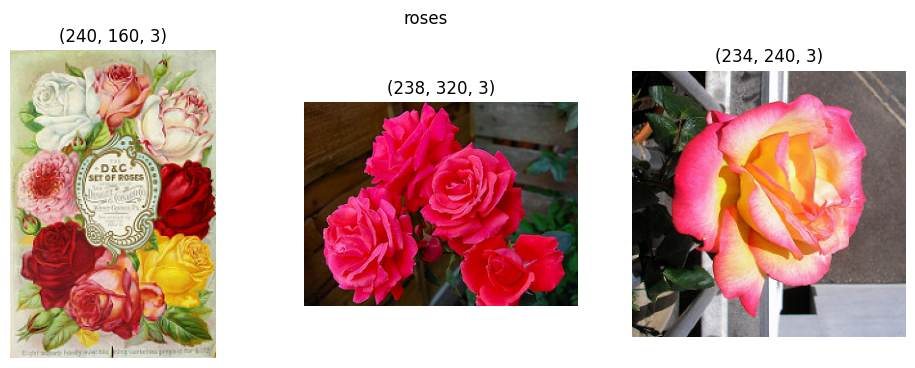

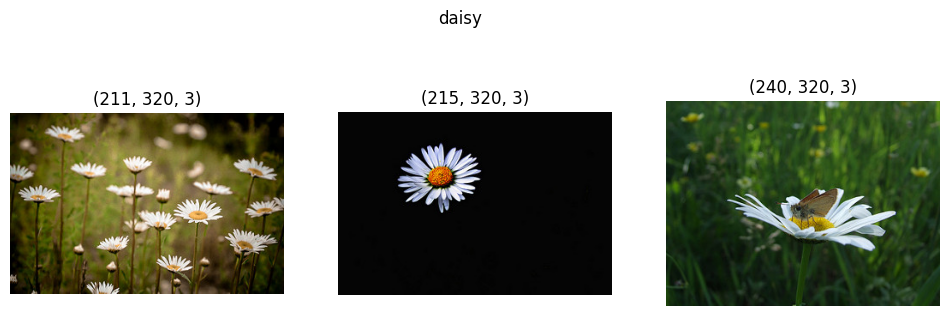

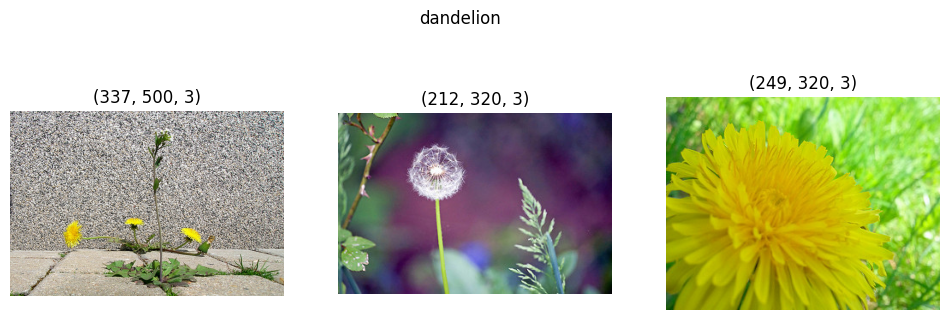

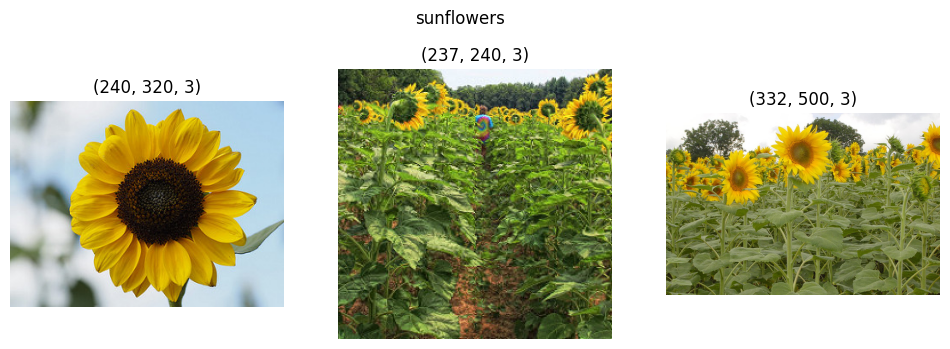

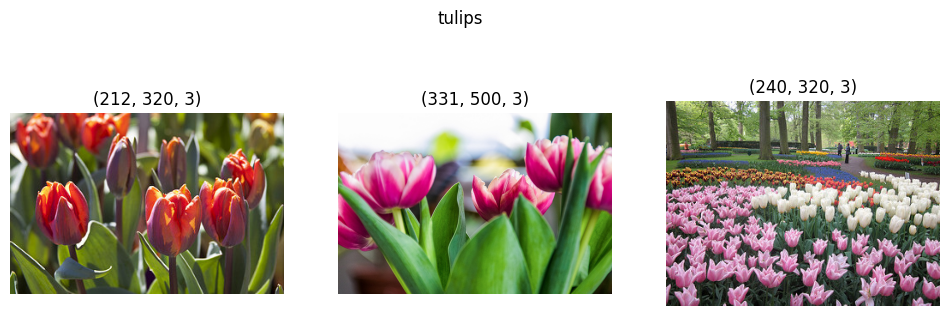

In [ ]:

for cl in classes:

    ruta_clase = os.path.join(train_dir, cl)

    # Obtener las 3 primeras imágenes
    imagenes = os.listdir(ruta_clase)[:3]

    plt.figure(figsize=(12,4))

    for i, img_name in enumerate(imagenes):

        img_path = os.path.join(ruta_clase, img_name)

        # Abrir imagen
        img = Image.open(img_path)

        # Convertir a array numpy
        img_array = np.array(img)

        # Mostrar imagen
        plt.subplot(1, 3, i+1)
        plt.imshow(img_array)

        # Título = shape del array
        plt.title(img_array.shape)

        plt.axis('off')

    plt.suptitle(cl)
    plt.show()

# c) Modelo 1: CNN básica (objetivo: accuracy_valid > 60%)


Implemente una red convolucional para resolver el problema de clasificación. Para ello se sugiere una CNN con 3 capas convolucionales + pooling con la siguiente estructura:

Bloque de procesamiento de imagen:
1.   32 kernels -> 64 kernels -> 96 kernels
2.   kernels de 3x3.
3.   Stride = 1 y padding = SI.
4.   Función de activación ReLU.
5.   Maxpooling de 2x2 con stride clásico de 2 pixeles.
6.   Igualamos el tamaño de todas las imágenes a 150 x 150.

Bloque de decisión:
7.   Capa densa de 512 neuronas.
8.   Capa densa de salida.

**Tarea 4: Define un modelo con la estructura anterior**



In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = keras.Sequential()

# Conv 1
model.add(keras.layers.Conv2D(
    32, (3, 3),
    activation='relu',
    padding='same',
    strides=(1, 1),
    input_shape=(150, 150, 3),
    name='conv1'
))

# Pool 1
model.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))

# Conv 2
model.add(keras.layers.Conv2D(
    64, (3, 3),
    activation='relu',
    padding='same',
    strides=(1, 1),
    name='conv2'
))
# Pool 2
model.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))

# Conv 3
model.add(keras.layers.Conv2D(
    96, (3, 3),
    activation='relu',
    padding='same',
    strides=(1, 1),
    name='conv3'
))
# Pool 3
model.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))

# Flatten
model.add(keras.layers.Flatten())

# Dense 1
model.add(keras.layers.Dense(512, activation='relu', name='densa1'))

# Output
model.add(keras.layers.Dense(5, activation='softmax', name='densa2'))

**Tarea 5: Indica el shape de la imagen antes y después de cada capa de la red. Explica cómo has obtenido dichos valores**

|Capa| Shape a la salida| #parámetros |
|:-|:-:|:-:|
|Conv_1|(150, 150, 32)|896
|Pool_1|(75, 75, 32)| 0
|Conv_2|(75, 75, 64)| 18.496
|Pool_2|(37, 37, 64)| 0
|Conv_3|(37, 37, 96)|55.392
|Pool_3|(18, 18, 96)| 0
|flatten|(31104)| 0
|densa_1|(512)| 15.925.760
|densa_2|(5)| 2.565

La red recibe imágenes con shape (150, 150, 3) 150x150 pixeles y 3 canales RGB.

**Conv_1** => El shape se mantiene igual excepto por el último valor, el "número de capas" será igual al número de kernels que procesan la imagen (filtros).
Usa 32 kernels 3x3, el número de parámetros será

    32*(3 * 3 * 3 + 1) = 896 parámetros.

*32 kernels, cada uno con 3x3 pesos, cada kernel aplicado a 3 canales de entrada (pesos diferentes para cada canal) más 1 bias cada kernel.*


**Pool_1** => Al usar un pooling de 2x2 con stride 2, el tamaño se reduce a la mitad: 150/2 = 75. El número de canales se mantiene igual. Las capas de pooling no tienen parámetros.

    Sin parámetros

**Conv_2** => Igual que Conv_1, solo cambian los canales, en este caso se usan 64 kernels.


Usa 64 kernels 3x3 aplicados a 32 canales:

    64*(3 * 3 * 32 + 1) = 18.496 parámetros.

**Pool_2** => Igual que Pool_1, reduce 75/2 = 37.

    Sin parámetros.


**Conv_3** => Igual que Conv_1 y Conv_2, solo cambian los canales, en este caso se usan 96 kernels.

Usa 96 kernels 3x3 aplicados a 64 canales:

    96*(3 * 3 * 64 + 1) = 55.392 parámetros.


**Pool_3** => Igual que Pool_1 y Pool_2, reduce 37/2 = 18.

    Sin parámetros.


**Flatten** => "Aplana" el resultado de la capa anterior:
    
    18 * 18 * 96 = 31104 (tamaño vector aplanado).

Solo aplana, no tiene parámetros


**Densa_1** => Tiene 512 neuronas. Cada output de la capa anterior (flatten) se conecta a cada neurona de densa_1:

    31104 * 512 + 512 (bias) = 15.925.760 parámetros.


**Densa_2** => Tiene 5 neuronas. Cada output de la capa anterior (densa_1) se conecta a cada neurona de densa_2,
    
    512 * 5 + 5 = 2.565 parámetros.




**Tarea 6: Compara el resultado con un summary() del modelo**


In [ ]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 37, 37, 96)     │        55,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 18, 18, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 31104)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densa1 (Dense)                  │ (None, 512)            │    15,925,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densa2 (Dense)                  │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,003,109 (61.05 MB)

 Trainable params: 16,003,109 (61.05 MB)

 Non-trainable params: 0 (0.00 B)

El resultado es identico al esperado.

**Tarea 7: Entrena el modelo de manera que obtenga un accuracy (sobre el conjunto de validación) > 60%.**

* Utilice el optimizador que considere más adecuado.
*   Recuerda que si no se realiza conversión a One-Hot de la etiqueta a predecir, debes utilizar como función de error `SparseCategoricalCrossentropy` (este es el procedimiento que hemos usado en clase).
*   Considera un learning rate en el entorno de 0.001.
*   En el caso de los generators utiliza `class_mode='sparse'`.
*   Puedes utilizar p.e. un `batch_size = 100`.

In [ ]:
# Generadores:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=100,
    class_mode='sparse'
)

validation_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(150, 150),
    batch_size=100,
    class_mode='sparse'
)

Found 2935 images belonging to 5 classes.
Found 735 images belonging to 5 classes.


In [ ]:
es_callback = keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True)

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
      train_generator,
      epochs=20,
      validation_data=validation_generator,
      callbacks=[es_callback],
      verbose=2)

Epoch 1/20
30/30 - 14s - 458ms/step - accuracy: 0.3135 - loss: 1.6683 - val_accuracy: 0.4544 - val_loss: 1.2589
Epoch 2/20
30/30 - 8s - 252ms/step - accuracy: 0.5581 - loss: 1.0964 - val_accuracy: 0.5905 - val_loss: 1.0429
Epoch 3/20
30/30 - 8s - 274ms/step - accuracy: 0.6184 - loss: 0.9603 - val_accuracy: 0.6136 - val_loss: 1.0125
Epoch 4/20
30/30 - 9s - 292ms/step - accuracy: 0.6845 - loss: 0.8122 - val_accuracy: 0.6422 - val_loss: 0.9659
Epoch 5/20
30/30 - 7s - 240ms/step - accuracy: 0.7295 - loss: 0.7072 - val_accuracy: 0.6327 - val_loss: 0.9934
Epoch 6/20
30/30 - 8s - 267ms/step - accuracy: 0.7986 - loss: 0.5591 - val_accuracy: 0.6449 - val_loss: 1.0065
Epoch 7/20
30/30 - 7s - 246ms/step - accuracy: 0.8746 - loss: 0.3830 - val_accuracy: 0.6381 - val_loss: 1.1857
Epoch 8/20
30/30 - 8s - 259ms/step - accuracy: 0.9199 - loss: 0.2457 - val_accuracy: 0.6259 - val_loss: 1.3035


**Tarea 8: Muestra la evolución de la función de error (train y valid) durante el entrenamiento.Explica que problema presenta el modelo que hemos entrenado.**

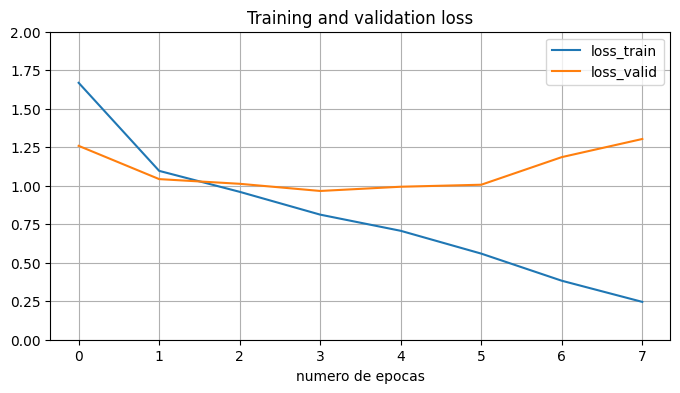

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

pd.DataFrame({'loss_train': history.history['loss'],
              'loss_valid': history.history['val_loss']}).plot(figsize=(8,4))

plt.grid(True)
plt.ylim(0,2)
plt.xlabel('numero de epocas')
plt.title('Training and validation loss');

## Analisis de los resultados obtenidos:

El modelo tiende **enormemente** al sobreajuste. Consigue muy buenos resultados en los datos de entrenamiento y vemos como mejora en cada epoch. Sin embargo, los resultados en validación son mediocres. Además está empeorando en cada epoch.

# d) Modelo 2: reducción del overfitting (objetivo: accuracy_valid > 70%)

Para mejorar el accuracy del modelo, vamos a incorporar las dos técnicas más habituales de reducción del overfitting:

    * drop-out
    * data augmentation
    

**Tarea 9: Explica en que consisten y qué utilidad tienen para nuestro problema**





- El drop-out implica el "apagado" de neuronas en la etapa de entrenamiento. Esto quiere decir que obligamos al modelo a no usar algunas de sus neuronas en cada paso del entrenamiento impidiendo que se activen. El drop-out ayuda a reducir el overfitting evitando que el modelo dependa de ciertas neuronas para las predicciones obligándolo a aprender a predecir de una forma general a partir de todas sus neuronas.

- El data-augmentation consiste en la generación de datos artificiales por ejemplo con rotación, zoom, flips...
Estos datos artificiales reducen el overfitting ya que en vez de hacer pasadas a un mismo conjunto de entrenamiento, el modelo recibe imagenes ligeramente alteradas que dificultan la memorización en los diferentes epochs.

**Tarea 10: Construye un nuevo modelo 2 incorporando (en el modelo 1 anterior) el dropout adecuado**

In [ ]:
model2 = keras.Sequential()

# Conv 1
model2.add(keras.layers.Conv2D(
    32, (3, 3),
    activation='relu',
    padding='same',
    strides=(1, 1),
    input_shape=(150, 150, 3),
    name='conv1'
))

# Pool 1
model2.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))

# Conv 2
model2.add(keras.layers.Conv2D(
    64, (3, 3),
    activation='relu',
    padding='same',
    strides=(1, 1),
    name='conv2'
))
# Pool 2
model2.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))

# Conv 3
model2.add(keras.layers.Conv2D(
    96, (3, 3),
    activation='relu',
    padding='same',
    strides=(1, 1),
    name='conv3'
))
# Pool 3
model2.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))

# Flatten
model2.add(keras.layers.Flatten())

# Dense 1
model2.add(keras.layers.Dense(512, activation='relu', name='densa1'))

# NUEVA CAPA DE DROPOUT
model2.add(keras.layers.Dropout(0.5))

# Output
model2.add(keras.layers.Dense(5, activation='softmax', name='densa2'))

**Tarea 11: Explica que tipos de augmentation vas a considerar y que utilidad tienen en nuestro problema de clasificacion**

Al tratarse de un dataset de flores, en general podemos aplicar casi cualquier tipo de augmentation que se nos ocurra: horizontal-flip, rotaciones ligeras, zoom, cambios leves de brillo...

Quizá no sería tan útil hacer cambios drásticos en los colores ya que las flores son bastante dependientes de su color. Tampoco nos vendrá bien aplicar vertical-flip, algunas flores del dataset aparecen con una vista desde arriba, en esas no habria problema. Sin embargo hay algunas en las que aparece la flor completa desde el tallo y aplicar un vertical-flip cambiaría bastante el concepto de flor.

**Tarea 12: Entrena el modelo de manera que obtenga un accuracy (sobre el conjunto de validación) > 70%.**

In [ ]:
train_datagen_augmentation = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,)

val_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
# Generadores:
train_generator_augmentation = train_datagen_augmentation.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=100,
    class_mode='sparse'
)

validation_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(150, 150),
    batch_size=100,
    class_mode='sparse'
)

Found 2935 images belonging to 5 classes.
Found 735 images belonging to 5 classes.


In [ ]:
model2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [ ]:
history2 = model2.fit(
      train_generator_augmentation,
      epochs=20,
      validation_data=validation_generator,
      callbacks=[es_callback],
      verbose=2)

Epoch 1/20
30/30 - 32s - 1s/step - accuracy: 0.3274 - loss: 1.5592 - val_accuracy: 0.4884 - val_loss: 1.2049
Epoch 2/20
30/30 - 25s - 817ms/step - accuracy: 0.4981 - loss: 1.1874 - val_accuracy: 0.5714 - val_loss: 1.1220
Epoch 3/20
30/30 - 25s - 822ms/step - accuracy: 0.5520 - loss: 1.0974 - val_accuracy: 0.5769 - val_loss: 1.0901
Epoch 4/20
30/30 - 25s - 844ms/step - accuracy: 0.5830 - loss: 1.0605 - val_accuracy: 0.6395 - val_loss: 0.9520
Epoch 5/20
30/30 - 27s - 903ms/step - accuracy: 0.6095 - loss: 0.9706 - val_accuracy: 0.6000 - val_loss: 1.0346
Epoch 6/20
30/30 - 25s - 836ms/step - accuracy: 0.6201 - loss: 0.9470 - val_accuracy: 0.6721 - val_loss: 0.8822
Epoch 7/20
30/30 - 25s - 832ms/step - accuracy: 0.6491 - loss: 0.8825 - val_accuracy: 0.7034 - val_loss: 0.8335
Epoch 8/20
30/30 - 27s - 904ms/step - accuracy: 0.6467 - loss: 0.8793 - val_accuracy: 0.6830 - val_loss: 0.8635
Epoch 9/20
30/30 - 25s - 835ms/step - accuracy: 0.6705 - loss: 0.8414 - val_accuracy: 0.6830 - val_loss: 0.

**Tarea 13: Muestra la evolucion de la funcion de error durante el entrenamiento. Explica qué diferencias de comportamiento hay entre las gráficas del modelo 1 y el modelo 2**

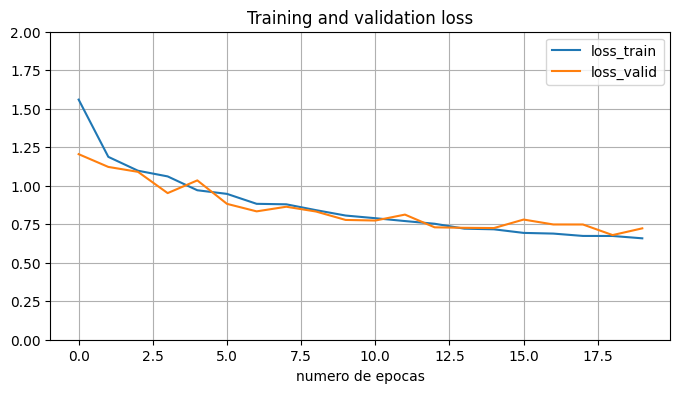

In [ ]:
pd.DataFrame({'loss_train': history2.history['loss'],
              'loss_valid': history2.history['val_loss']}).plot(figsize=(8,4))

plt.grid(True)
plt.ylim(0,2)
plt.xlabel('numero de epocas')
plt.title('Training and validation loss');

## Analisis de los resultados obtenidos:

Como podemos ver en este caso, las pérdidas entre entrenamiento y validación están mucho más cercanas entre ellas. Ambas mejoran simultáneamente a lo largo de las iteraciones.

Hay algunos picos en el dataset de validación que implican que el modelo ha empeorado en esas épocas, sin embargo al configurar una paciencia de 4, las mejoras posteriores hacen que el modelo siga entrenando y mejorando más consiguiendo un accuracy del 75%, mucho más alto que antes.

# c) Modelo 3: Transfer Learning (objetivo: accuracy_valid > 88%)

En nuestro problema de clasificación de flores, el utilizar CNNs diseñadas y entrenadas por nosotros mismos, aparece una barrera en las proximidades del 75-77% de precisión del modelo (siempre sobre validación).

Para superar este escollo, el siguiente paso natural es la utilización de modelos preentrenados. Existe una gran variedad de ellos basados en redes CNNs clásicas, donde la principal diferencia es que acumulan más capas que nuestros modelos 1 y 2. Adicionalmente, en estos modelos se han ido incorporando diferentes propuestas para mejorar la arquitectura de la CNN.

En general, utilizando estos modelos convolucionales preentrenados podemos alcanzar accuracies próximos al 90%. Normalmente, estos modelos han sido previamente entrenados sobre datasets de gran tamaño y con gran número de categorías. P.e. en subconjuntos de Imagenet (14 millones de imagenes de 22K categorías).

Dado que estos modelos se entrenaron para resolver un problema "relativamente" parecido a nuestro problema de clasificación, parece razonable pensar que podemos aprovechar ese conocimiento capturado en la red para resolver nuestro problema de clasificación de flores.



Para elegir el modelo preentrenado que debe utilizar cada grupo, proceda del siguiente modo:
* Paso 1: sume los DNIs de los componentes del grupo (si el grupo tiene un sólo miembro, vaya directamente al paso 2). res = dni_1 + dn_2
* Paso 2: Aplique la siguiente operación al resultado anterior: res mod 6.
* Paso 3: Tome el modelo cuyo número asociado coincide con el resultado de la operación anterior.
* Paso 4: El porcentaje que aparece entre paréntesis junto al nombre del modelo es el accuracy (en validación) que deberías poder alcanzar sin dificultad utilizando el modelo. En todos los casos considera un input_shape = (224, 224, 3).

  0. Resnet50 (>90%)
  https://www.tensorflow.org/api_docs/python/tf/keras/applications/resnet50/ResNet50

  1. Resnet101 (>90%) input_shape = (224, 224, 3)
  https://www.tensorflow.org/api_docs/python/tf/keras/applications/resnet/ResNet101

  2. VGG16 (>90%) input_shape = (224, 224, 3)
  https://www.tensorflow.org/api_docs/python/tf/keras/applications/vgg16/VGG16

  3. VGG19 (>90%) input_shape = (224, 224, 3) https://www.tensorflow.org/api_docs/python/tf/keras/applications/vgg19/VGG19

  4. Xception (>88%) input_shape = (224, 224, 3) https://www.tensorflow.org/api_docs/python/tf/keras/applications/xception/Xception

  5. Inceptionv3 (>88%) input_shape = (224, 224, 3) https://www.tensorflow.org/api_docs/python/tf/keras/applications/inception_v3/InceptionV3

P.e. si los DNIs de los alumnos son: 12345678 y 23456781. La suma es 35802459. De donde 35802459 mod 6 = 3. Por tanto, tomaríamos el modelo VGG16.

Recuerda que puedes utilizar el siguiente post como referencia del uso de transfer learning: https://www.learndatasci.com/tutorials/hands-on-transfer-learning-keras/

In [ ]:
dni1 = 47349866
dni2 = 20953450
print(f"Cálculo de los DNIs obtenido: {(dni1 + dni2)%6}")

Cálculo de los DNIs obtenido: 0


Usaremos el modelo Resnet50 y buscaremos un accuracy >90%

**Tarea 14: Importa el modelo desde Tensorflow**

Dado que este modelo ha sido entrenado para clasificar entre 1.000 categorías, las capas densas finales del modelo no son útiles para nuestro problema de clasificación de 5 categorías (es lo que suele llamarse include_top = SI/NO). De manera que eliminamos lo que a veces se suele llamar el "top model". De este modo sólo nos quedamos con la parte que hace la funcionalidad de "procesamiento" de la imagen.

In [ ]:
resnet50 = keras.applications.ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


**Tarea 15: Personalizar el bloque de decisión**  
Añadimos una capa de flatten y tres nuevas capas densas especificas para nuestro problema con dimensiones 4096, 1072 y la que necesite la capa de salida (con sus correspondientes drop-outs).

In [ ]:
model3 = keras.Sequential()

# Añadimos las capas de "extracción" del modelo resnet50
model3.add(resnet50)

# A partir de aqui añadimos las capas encargadas de clasificar las flores.
model3.add(layers.Flatten())

# Dense 1
model3.add(layers.Dense(4096, activation='relu'))
model3.add(layers.Dropout(0.5))

# Dense 2
model3.add(layers.Dense(1072, activation='relu'))
model3.add(layers.Dropout(0.5))

# Output
model3.add(layers.Dense(5, activation='softmax'))

In [ ]:
model3.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4096)           │   411,045,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1072)           │     4,391,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │         5,365 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 439,030,949 (1.64 GB)

 Trainable params: 438,977,829 (1.64 GB)

 Non-trainable params: 53,120 (207.50 KB)

**Tarea 16: Congelar los pesos que no se vayan a entrenar**

Previo a hacer el denominado `Fine-Tuning` del modelo, indicaremos a Tensorflow que únicamente debe entrenar:

   * Las dos últimas capas convolucionales de la red preentrenada, de las que realizaremos un ajuste fino de los pesos.
   * Las tres capas densas que hemos incluido nuevas.

In [ ]:
for layer in resnet50.layers:
    layer.trainable = False

for layer in resnet50.layers[-2:]:
    layer.trainable = True

**Tarea 17: Crear los datagenerators oportunos**

Para ello:
> * Utiliza Data augmentation.  
> * Las imágenes tienen que ser preprocesadas igual que cuando se entrenó el modelo pre.entrenado original. Para ello se utiliza el parámetro `preprocessing_function=preprocess_input` (preprocess_input importado desde `keras.applications.xxxxxx` en ambos generators (train y valid). Por tanto, no hay que indicarle `rescale`. En caso de ser necesario, se encargará `preprocess_input`.  
> * Dado que estamos reutilizando un modelo que no "es nuestro", deberemos ceñirnos al tamaño de imagen que permite la red a la entrada. Recuerda que debe ser: 224x224.

In [ ]:
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse'
)

validation_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse'
)

Found 2935 images belonging to 5 classes.
Found 735 images belonging to 5 classes.


**Tarea 18: Haz el fine-tuning del modelo con el objetivo de alcanzar un accuracy (sobre el conjunto de validación > 88%).**

A la hora de entrenar un modelo pretrained es típico bajar el learning rate respecto al que utilizaríamos para un modelo nuestro desde cero.

In [ ]:
model3.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [ ]:
history = model3.fit(
    train_generator,
    epochs=15,
    validation_data=validation_generator,
    callbacks=[es_callback],
    verbose=1
)

Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 88s 761ms/step - accuracy: 0.5721 - loss: 2.0238 - val_accuracy: 0.8531 - val_loss: 0.4257
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 47s 514ms/step - accuracy: 0.7230 - loss: 1.0939 - val_accuracy: 0.8980 - val_loss: 0.3284
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 47s 505ms/step - accuracy: 0.7642 - loss: 0.8746 - val_accuracy: 0.8980 - val_loss: 0.3072
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 47s 512ms/step - accuracy: 0.7990 - loss: 0.7453 - val_accuracy: 0.9102 - val_loss: 0.2623
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 47s 512ms/step - accuracy: 0.8164 - loss: 0.6404 - val_accuracy: 0.9061 - val_loss: 0.2627
Epoch 6/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 46s 504ms/step - accuracy: 0.8303 - loss: 0.5980 - val_accuracy: 0.9156 - val_loss: 0.2750
Epoch 7/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 49s 527ms/step - accuracy: 0.8422 - loss: 0.5429 - val_accuracy: 0.9156 - val_loss: 0.2595
Epoch 8/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 47s 514ms/step - accuracy: 0.8552 - loss: 0.4914 - val_accu

In [ ]:
print(train_generator.class_indices)

{'daisy': 0, 'dandelion': 1, 'roses': 2, 'sunflowers': 3, 'tulips': 4}


/root/.keras/datasets/flower_photos_extracted/flower_photos/val/tulips/7166567320_0a2beb6d42.jpg


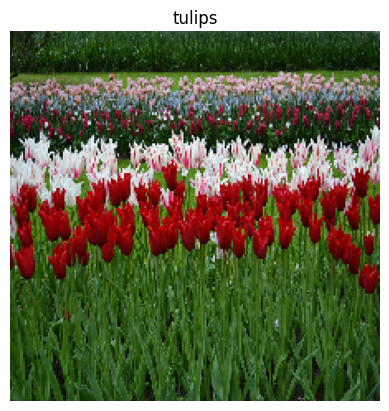

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Predicción: tulips


In [ ]:
from tensorflow.keras.preprocessing import image


base_dir = os.path.expanduser("~/.keras/datasets/flower_photos_extracted/flower_photos/val")

class_name = "tulips"

class_dir = os.path.join(base_dir, class_name)

img_name = (os.listdir(class_dir))[9]
img_path = os.path.join(class_dir, img_name)

print(img_path)

img = image.load_img(img_path, target_size=(224, 224))

plt.imshow(img)
plt.title(class_name)
plt.axis('off')
plt.show()

x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

pred = model3.predict(x)

class_names = ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


print("Predicción:", class_names[np.argmax(pred)])